<a href="https://www.kaggle.com/code/prince70015/stock-price-prediction?scriptVersionId=323453643" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**FIND THE STOCK FILE**# 

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames[:20]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/ufi.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/vfl.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/sohu.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/rdcm.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/virt.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/hylb.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/skt.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/asix.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/mac.us.txt
/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/gut.us.txt
/kaggle/input/d

# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2026-05-31 14:37:30.764796: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780238250.995602      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780238251.065677      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780238251.598889      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780238251.598932      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780238251.598935      22 computation_placer.cc:177] computation placer alr

# LOAD THE DATA

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/sohu.us.txt"
)

print(df.shape)
df.head()

(3201, 7)


,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,16.46,16.89,16.46,16.83,874643,0
1,2005-02-28,16.75,18.30,16.75,17.92,3676074,0
2,2005-03-01,17.87,19.23,17.86,18.80,3574093,0
3,2005-03-02,18.68,18.89,18.10,18.28,1709915,0
4,2005-03-03,18.41,19.31,18.27,18.94,2947206,0


# CHECK COLUMNS

In [4]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')


In [5]:
print(df.columns)
print(df.shape)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')
(3201, 7)


# CONVERT DATE

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,16.46,16.89,16.46,16.83,874643,0
1,2005-02-28,16.75,18.30,16.75,17.92,3676074,0
2,2005-03-01,17.87,19.23,17.86,18.80,3574093,0
3,2005-03-02,18.68,18.89,18.10,18.28,1709915,0
4,2005-03-03,18.41,19.31,18.27,18.94,2947206,0


# MOVING AVERAGES

In [7]:
df['MA20'] = df['Close'].rolling(20).mean()

df['MA50'] = df['Close'].rolling(50).mean()

# RSI

In [8]:
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

# REMOVE MISSING VALUES

In [9]:
df = df.dropna()

print(df.shape)

(3152, 10)


# USE CLOSE PRICE

In [10]:
data = df[['Close']].values

# NORMALLIZE

In [11]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

# CREATE SEQUENCES

In [12]:
X = []
y = []

for i in range(60, len(data_scaled)):
    X.append(data_scaled[i-60:i, 0])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

X = np.reshape(
    X,
    (X.shape[0], X.shape[1], 1)
)

print(X.shape)
print(y.shape)

(3092, 60, 1)
(3092,)


# TRAIN-TEST-SPLIT

In [13]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# BUILD LSTM

In [14]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=False,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

I0000 00:00:1780238265.881036      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780238265.886932      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

# TRAIN MODEL

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20


I0000 00:00:1780238269.166981      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0164 - val_loss: 9.8052e-04
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017 - val_loss: 8.6518e-04
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 8.1703e-04
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 7.2072e-04
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012 - val_loss: 6.3110e-04
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 8.6096e-04
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 7.2609e-04
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.8145e-04 - val_loss: 5.0562e-04
Epoch 9/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.6604e-04 - val_loss: 5.3064e-04
Epoch 10/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.6781e-04 - val_loss: 4.7577e-04
Epoch 11/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.8938e-04 - val_loss: 4.3798e-04
Epoch 12/20
78/78 ━━━━━━

# PREDICTION

In [16]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


# RMSE

In [17]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 2.1171432382938784


# ACTUAL VS PREDICTED

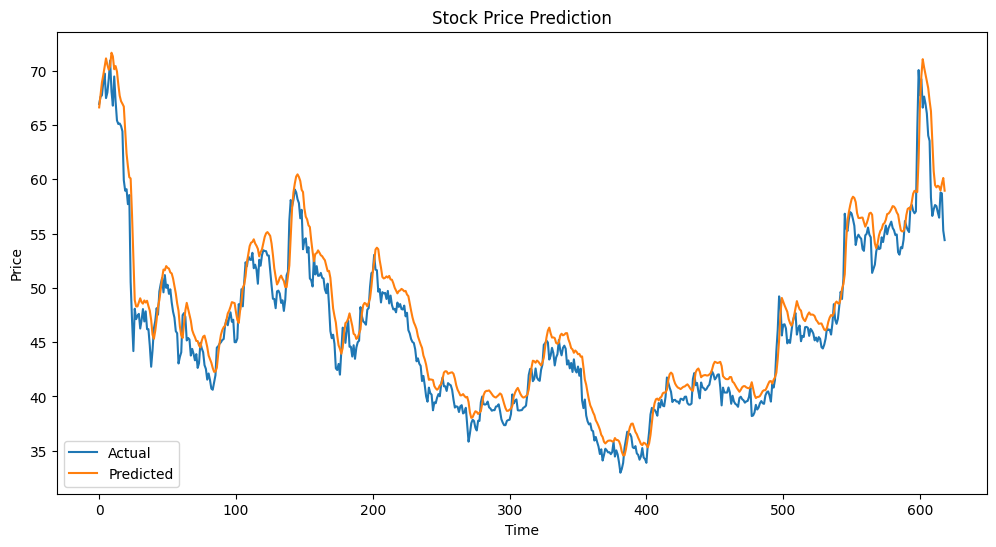

In [18]:
plt.figure(figsize=(12,6))

plt.plot(actual, label='Actual')

plt.plot(predictions, label='Predicted')

plt.title('Stock Price Prediction')

plt.xlabel('Time')

plt.ylabel('Price')

plt.legend()

plt.show()

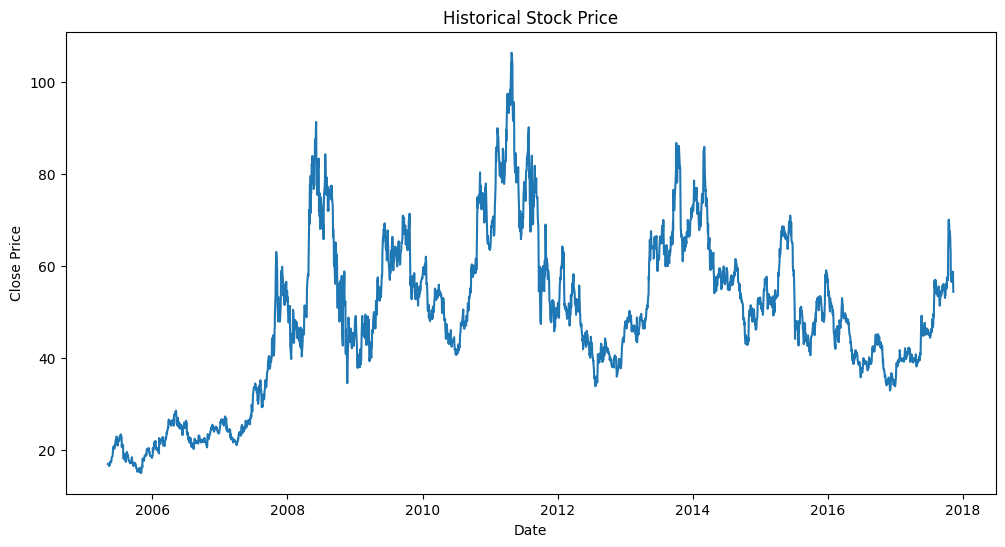

In [19]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'])

plt.title("Historical Stock Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()